In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager as fm

font_path = "/home/achieveho/.local/share/fonts/noto-sans-kr/NotoSansKR-Regular.ttf"

fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

print("적용 폰트 이름:", font_name)

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("국민건강보험공단_건강검진정보_2023.CSV", encoding="euc-kr")

적용 폰트 이름: Noto Sans KR


In [3]:
import matplotlib as mpl
from matplotlib import font_manager as fm

font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"

print("matplotlib version:", mpl.__version__)
print("findSystemFonts에 경로가 있는가?:", font_path in fm.findSystemFonts())
print("fontManager.ttflist에 파일이 있는가?:", any(f.fname == font_path for f in fm.fontManager.ttflist))
print("fontManager.ttflist에 family가 있는가?:", any(f.name == "Noto Sans CJK KR" for f in fm.fontManager.ttflist))

matches = [f for f in fm.fontManager.ttflist if "Noto Sans CJK" in f.name]
for f in matches[:20]:
    print(f.name, "->", f.fname)

matplotlib version: 3.10.0
findSystemFonts에 경로가 있는가?: True
fontManager.ttflist에 파일이 있는가?: True
fontManager.ttflist에 family가 있는가?: False
Noto Sans CJK JP -> /usr/share/fonts/opentype/noto/NotoSansCJK-DemiLight.ttc
Noto Sans CJK JP -> /usr/share/fonts/opentype/noto/NotoSansCJK-Black.ttc
Noto Sans CJK JP -> /usr/share/fonts/opentype/noto/NotoSansCJK-Thin.ttc
Noto Sans CJK JP -> /usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc
Noto Sans CJK JP -> /usr/share/fonts/opentype/noto/NotoSansCJK-Light.ttc
Noto Sans CJK JP -> /usr/share/fonts/opentype/noto/NotoSansCJK-Medium.ttc
Noto Sans CJK JP -> /usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc


In [4]:
# 0. 건강검진정보 데이터를 시각화하기.
# 1. 데이터 전처리 및 데이터 시각화를 하기 위한 라이브러리 import.
# 2. 데이터를 다운로드 받아 dataframe 형태로 읽음.
# 3. 한글 깨짐을 방지하기 위해 인코딩을 'euc-kr'로 설정해야 함.
pd.set_option("display.expand_frame_repr", False)

In [5]:
df.head()

,기준년도,가입자일련번호,시도코드,성별코드,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),...,혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,치아우식증유무,결손치 유무,치아마모증유무,제3대구치(사랑니) 이상,치석
0,2023,34735,46,2,9,155,70,92.0,1.2,1.2,...,24.0,50.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN
1,2023,4105118,11,1,17,160,55,86.0,0.9,9.9,...,11.0,31.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN
2,2023,362482,36,2,13,150,65,96.0,1.0,0.8,...,29.0,24.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN
3,2023,653166,11,1,13,160,70,85.0,1.0,1.2,...,21.0,27.0,3.0,1.0,1,0.0,NaN,NaN,NaN,0.0
4,2023,4152237,41,1,12,165,65,84.5,1.0,1.2,...,33.0,49.0,3.0,1.0,0,NaN,NaN,NaN,NaN,NaN


In [6]:
df.describe()

,기준년도,가입자일련번호,시도코드,성별코드,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),...,혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,치아우식증유무,결손치 유무,치아마모증유무,제3대구치(사랑니) 이상,치석
count,1000000.0,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,999589.000000,999816.000000,999823.000000,...,994184.000000,994187.000000,999911.000000,999944.000000,1000000.000000,346848.000000,0.0,0.0,0.0,346848.000000
mean,2023.0,2.499892e+06,33.826110,1.484965,10.598531,162.683560,64.334995,81.322400,0.956662,0.954260,...,26.363751,35.382367,1.543575,0.659812,0.346848,0.158894,NaN,NaN,NaN,0.564008
std,0.0,1.443348e+06,12.543398,0.499774,3.046639,9.348951,13.864438,10.858057,0.575118,0.570776,...,26.100922,62.437751,0.788110,0.473772,0.475967,0.365578,NaN,NaN,NaN,0.570572
min,2023.0,3.000000e+00,11.000000,1.000000,5.000000,130.000000,30.000000,7.500000,0.100000,0.100000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000
25%,2023.0,1.250397e+06,27.000000,1.000000,8.000000,155.000000,55.000000,74.000000,0.700000,0.700000,...,15.000000,15.000000,1.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000
50%,2023.0,2.500716e+06,41.000000,1.000000,11.000000,165.000000,65.000000,81.000000,0.900000,1.000000,...,21.000000,22.000000,1.000000,1.000000,0.000000,0.000000,NaN,NaN,NaN,1.000000
75%,2023.0,3.749801e+06,43.000000,2.000000,13.000000,170.000000,75.000000,88.000000,1.200000,1.200000,...,30.000000,37.000000,2.000000,1.000000,1.000000,0.000000,NaN,NaN,NaN,1.000000
max,2023.0,5.000000e+06,49.000000,2.000000,18.000000,195.000000,135.000000,999.000000,9.900000,9.900000,...,6297.000000,9999.000000,3.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,2.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 33 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   기준년도           1000000 non-null  int64  
 1   가입자일련번호        1000000 non-null  int64  
 2   시도코드           1000000 non-null  int64  
 3   성별코드           1000000 non-null  int64  
 4   연령대코드(5세단위)    1000000 non-null  int64  
 5   신장(5cm단위)      1000000 non-null  int64  
 6   체중(5kg단위)      1000000 non-null  int64  
 7   허리둘레           999589 non-null   float64
 8   시력(좌)          999816 non-null   float64
 9   시력(우)          999823 non-null   float64
 10  청력(좌)          999863 non-null   float64
 11  청력(우)          999862 non-null   float64
 12  수축기혈압          994253 non-null   float64
 13  이완기혈압          994253 non-null   float64
 14  식전혈당(공복혈당)     994186 non-null   float64
 15  총콜레스테롤         338606 non-null   float64
 16  트리글리세라이드       338606 non-null   float64
 17  HDL콜레스테롤 

In [8]:
df.drop(['기준년도', '가입자일련번호', '결손치 유무', '치아마모증유무', '제3대구치(사랑니) 이상'], inplace=True, axis=1)

df.rename(columns={'연령대코드(5세단위)': '연령코드',
                   '신장(5cm단위)': '신장',
                   '체중(5kg단위)': '체중',
                   '식전혈당(공복혈당)': '혈당'}, inplace=True)

df = df.dropna()

In [9]:
df.head(20)

,시도코드,성별코드,연령코드,신장,체중,허리둘레,시력(좌),시력(우),청력(좌),청력(우),...,요단백,혈청크레아티닌,혈청지오티(AST),혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,치아우식증유무,치석
3,11,1,13,160,70,85.0,1.0,1.2,1.0,1.0,...,1.0,0.9,22.0,21.0,27.0,3.0,1.0,1,0.0,0.0
19,41,1,8,170,80,93.0,1.2,1.2,1.0,1.0,...,2.0,1.1,25.0,40.0,27.0,2.0,1.0,1,1.0,0.0
30,41,1,9,180,85,96.1,0.1,0.2,1.0,1.0,...,1.0,0.8,25.0,57.0,41.0,2.0,1.0,1,0.0,0.0
32,41,1,17,165,70,91.0,1.0,0.9,2.0,2.0,...,1.0,0.9,24.0,25.0,16.0,3.0,1.0,1,0.0,0.0
59,11,1,13,175,105,104.0,1.2,1.2,1.0,1.0,...,1.0,0.8,20.0,21.0,27.0,3.0,1.0,1,0.0,1.0
64,28,1,13,160,60,83.2,0.5,0.7,1.0,1.0,...,1.0,0.8,19.0,19.0,53.0,3.0,1.0,1,0.0,1.0
66,43,2,13,160,50,71.0,0.7,1.0,1.0,1.0,...,1.0,0.6,30.0,23.0,16.0,1.0,1.0,1,0.0,1.0
89,11,1,12,170,70,84.0,0.3,0.7,1.0,1.0,...,1.0,1.1,27.0,28.0,30.0,2.0,1.0,1,0.0,1.0
100,31,2,9,165,65,74.0,1.0,1.0,1.0,1.0,...,1.0,0.9,16.0,8.0,11.0,1.0,1.0,1,0.0,0.0
104,48,1,13,160,45,66.0,1.2,1.2,1.0,1.0,...,1.0,0.7,21.0,16.0,42.0,3.0,1.0,1,0.0,1.0


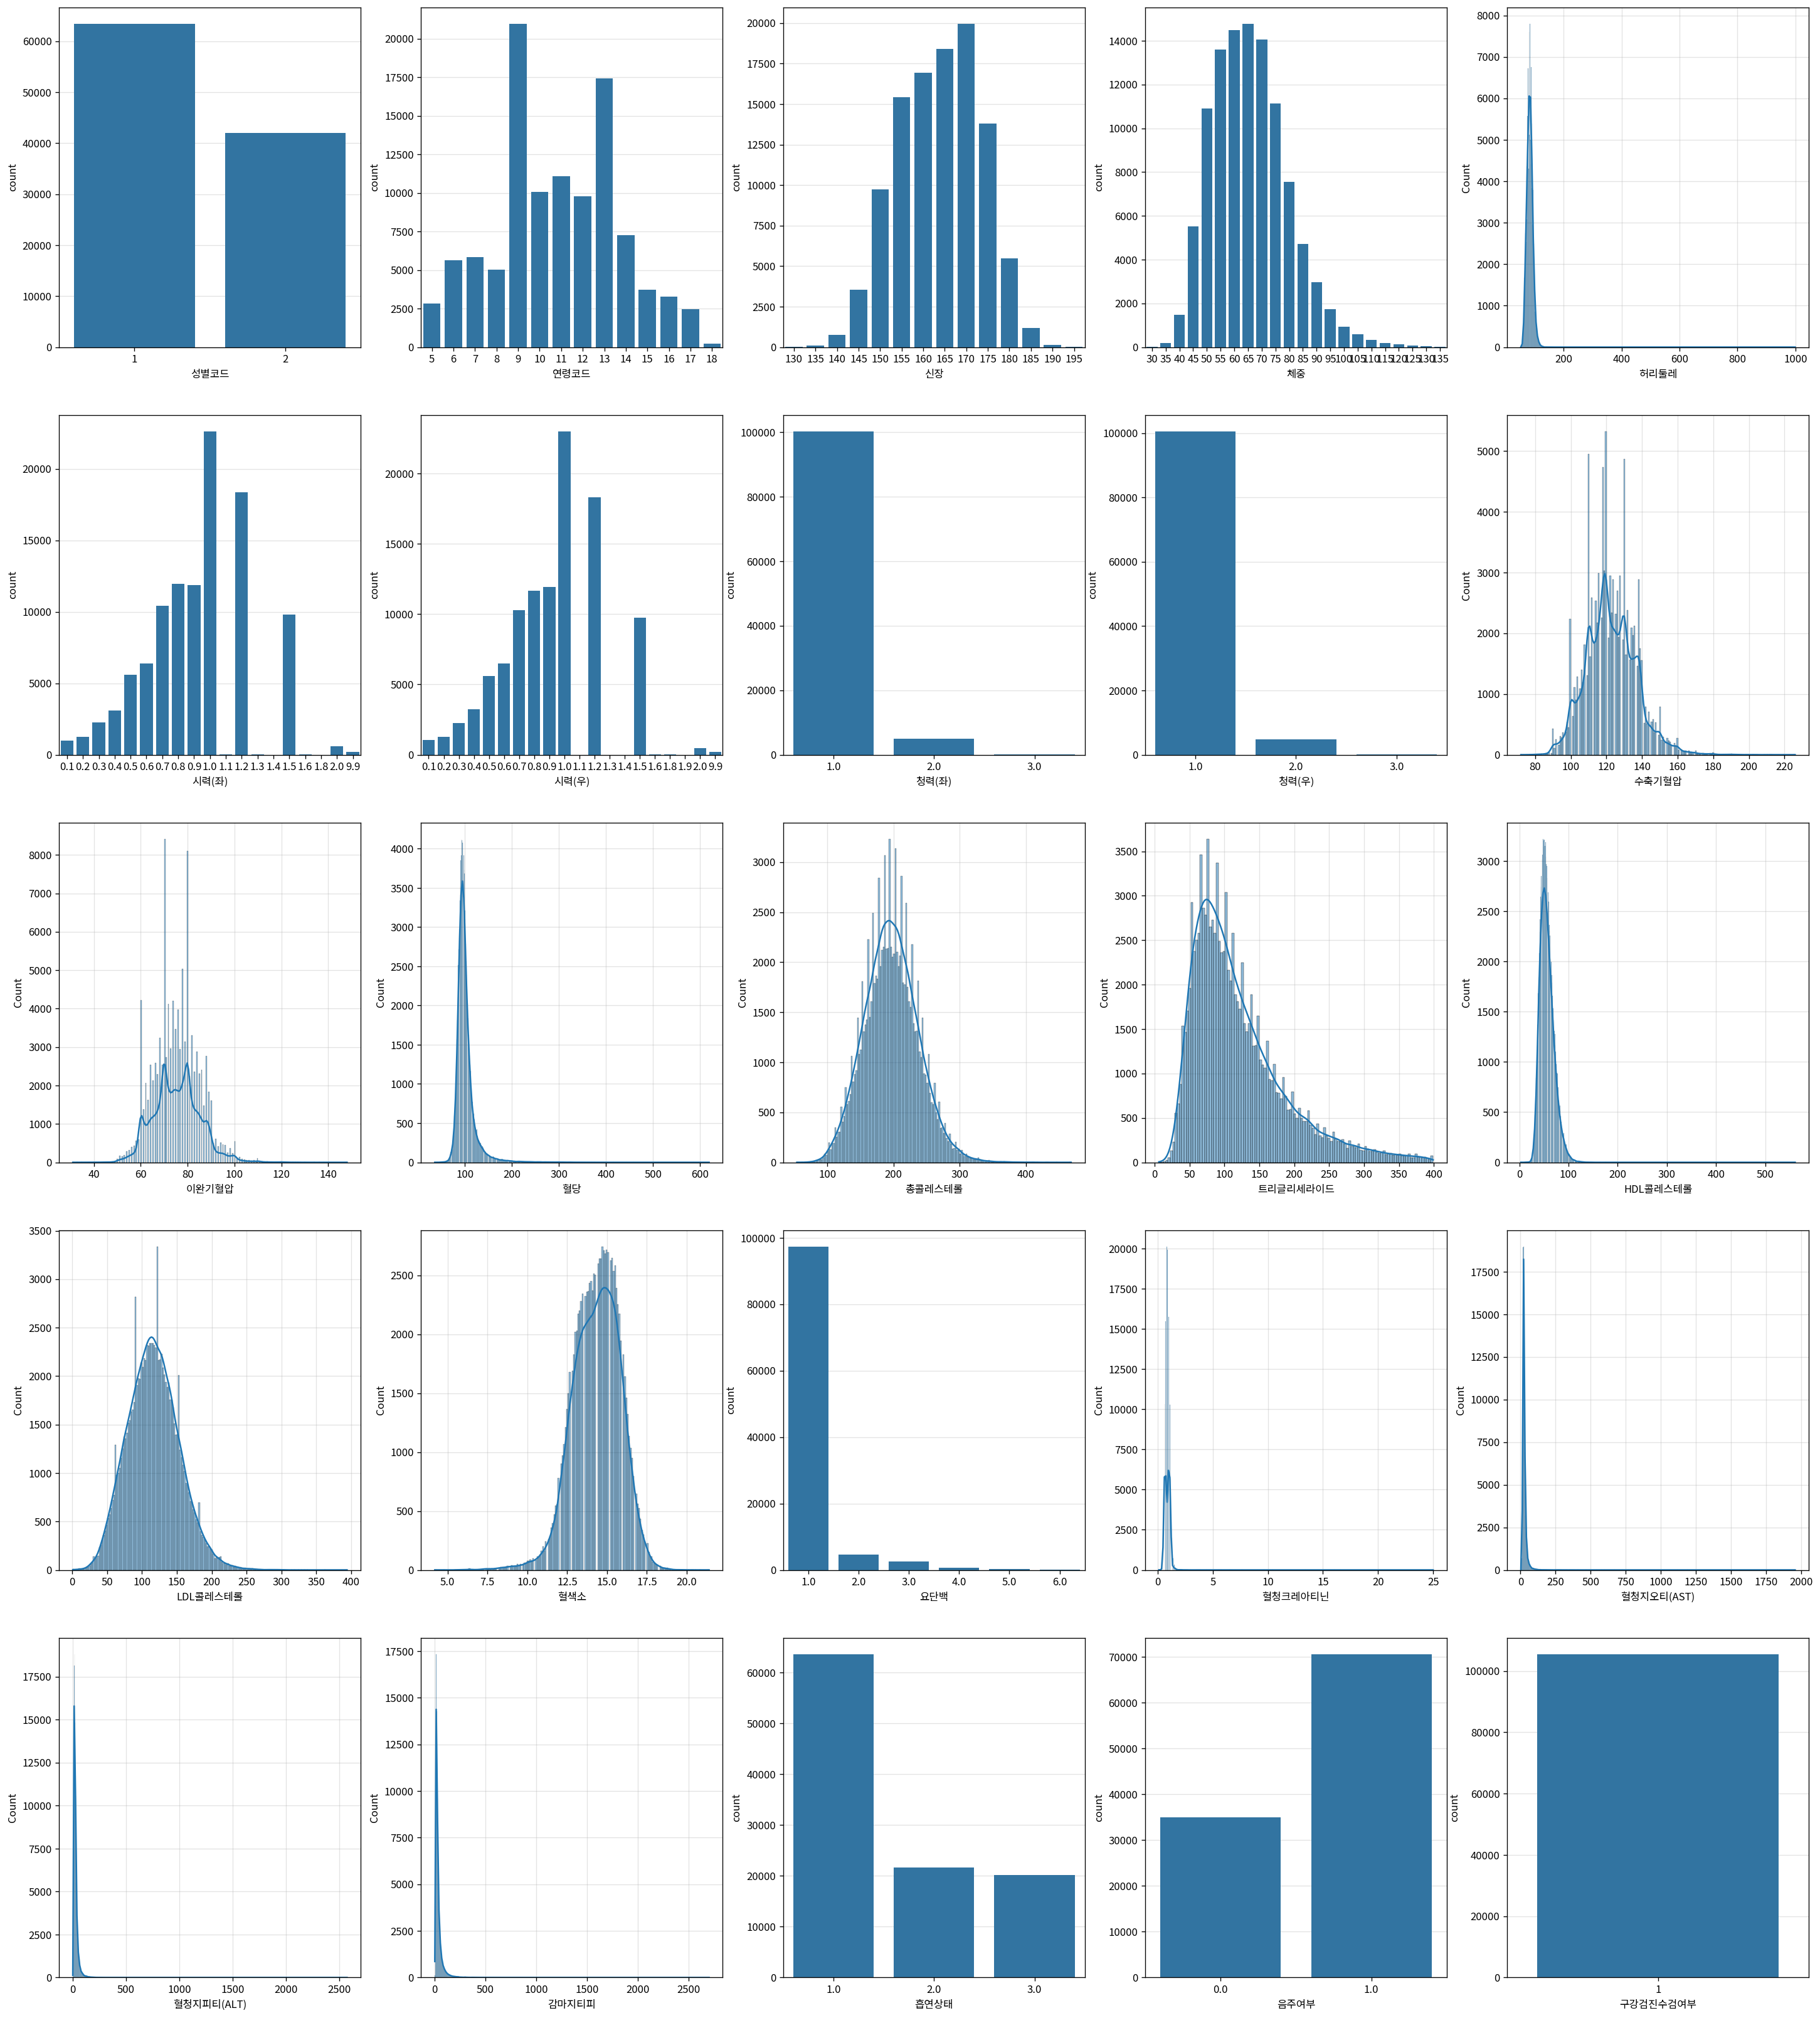

In [10]:
fig, axis = plt.subplots(5, 5)
fig.set_size_inches(30, 34)

for i in range(5):
    for j in range(5):
        attr = i * 5 + j + 1
        if df[df.columns[attr]].nunique() < 30:
              sns.countplot(x=df.columns[attr], data=df, ax=axis[i][j])
        else:
             sns.histplot(x=df.columns[attr], data=df, kde=True, ax=axis[i][j])

In [11]:
# 1. 성별코드
# 성별 코드는 1과 2인데, 신장으로 봤을 때 1이 male이고, 2가 female인 것으로 확인됨.
# 성별은 10만명 중 male 60%, male 40%로 구성되어 있음.

# 2. 연령코드
# 5세 단위라고 적혀있음.
# 5 = 25, 6 = 30, ... , 18 = 90 형태로 되어있는 것을 확인할 수 있음.
# 90대 이상인 사람의 수가 제일 적고, 40대와 60대가 제일 많이 있음.

# 3. 신장
# 단위는 cm.
# 남성 비율이 여성 비율보다 높기 때문에, 165 ~ 180 사이의 비율이 제일 많음.

# 4. 체중
# 이상한 체중(40kg 미만과 100kg 이상)도 조금 관찰됨.

# 5. 허리둘레
# 허리둘레는 x축 label이 좀 이상하게 나온 것 같음..
# x축의 값은 단위가 cm 인 것 같음.

# 6. 시력(좌, 우)
# 음수 값은 나오지 않았음.
# 시력이 9.9인 사람의 수가 있는 것으로 봐서는, 뭔가 조사 중 오류가 발생한 것 같음. 이상치이지 않을까 생각됨.
# 1.0인 사람이 제일 많고, 그 다음 1.2인 사람이 많음.
# 그리고 대부분은 0.9 이하에 포진되어 있음.
# 우측 눈의 시력과 좌측 눈의 시력은 거의 90% 동일한 양상을 보임.

# 7. 청력
# 청력도 시력과 같은 단위를 사용하는 것 같음. (1.0, 2.0 등)
# 청력이 3.0인 사람이 있는 것으로 조사되었는데, 여기서의 3.0은 이상치일까, 아니면 정상 범위 내의 값인걸까?
# 좌측과 우측 귀의 청력은 시력보다도 더 동일한 양상을 보임.

# 8. 수축기 혈압
# x축의 단위는 mmHg(밀리미터 수은주)
# '수축기 혈압' == '최고 혈압'
# 수축기 혈압: 심장이 수축하면서 혈액을 뿜어낼 때, 혈관 벽이 받는 최고의 압력.
# 정상 수치는 평균적으로 120mmHg 미만임.
# 120mmHg 이상인 사람들(고혈압 의심)도 꽤 관찰됨.

# 9. 이완기 혈압
# 역시 단위는 mmHg를 사용. (밀리미터 수은주)요단백
# '이완기 혈압' == '최저 혈압'
# 이완기 혈압: 심장이 수축을 멈추고 다음 박동을 위해 이완하며 혈액을 채우는 동안, 혈관 벽에 남아있는 압력.
# 보통 정상 수치는 80mmHg 미만.
# 80mmHg 이상인 사람들(고혈압 의심)이 꽤 관찰됨. (한 40% 정도 될 듯.)

# 10. 혈당
# x축 단위: mm/dL(밀리리터 퍼 데시리터)
# 100mg/dl은 혈액 100ml에 포도당 100mg이 들어있다는 의미.
# 이 혈당 데이터는 언제 측정한 데이터일까? 공복, 식전, 식후, 운동 전/후 등
# 혈당은 측정 시기에 따른 영향을 많이 받기에, 측정 시기를 아는 것이 중요함.

# 11. 총 콜레스테롤
# x축의 콜레스테롤의 값의 단위는 'mm/dL'임. (밀리미터 퍼 데시리터)
# 100mm/dL은 혈액 100ml에 콜레스테롤이 100mg 들어있다는 의미.
# 200mg/dL 미만이 정상 수치이며, 그 이상을 넘어가면 위험함.
# 현재의 그래프로만 보면, 총 콜레스테롤 수치에 LDL콜레스테롤, HDL콜레스테롤, 중성지방 등이 얼마나 포함되어 있는지 알 수 없음.
# 그래서 무조건 콜레스테롤이 높은 사람이 다 몸이 좋지 않다고 볼 수 없음.

# 12. 트리글리세라이드 (= 중성지방)
# 중성지방을 트리글리세라이드라고 함.
# 단위는 mm/dL (밀리미터 퍼 데시리터)
# 중성지방이 많은 사람들 모두가 총 콜레스테롤 수치가 높다고는 할 수 없겠지만, 확률 상으로는 높을 것 같음.
# 총 콜레스테롤 수치는 최댓값이 200 ~ 250 정도였는데, 트리글리세라이드는 값의 범위가 400까지도 있는 것으로 봐서, 총 콜레스테롤 지수 내에 포함되는 것이 아닌 것 같음.

# 13. HDL콜레스테롤
# 수치는 0~100 사이에 90% 이상의 사람들이 포진되어 있음.
# 혈액 내 콜레스테롤을 운반하는 지단백 중 하나로, 좋은 콜레스테롤에 해당함.
# 남성은 40mg/dL, 여성은 50mm/dL 이상이 정상 수치임.
# 하지만 수치가 너무 많이 높아도 좋지 않음.

# 14. LDL콜레스테롤
# 마찬가지로 혈중 콜레스테롤을 운반하는 지단백 중 하나이지만, 나쁜 콜레스테롤에 해당함.
# 100mg/dL 이하여야 정상 수치임.
# 100mg/dL 이상이 되면 동맥경화증을 유발함.
# 수치 상으로 100mg/dL 이하인 사람들과 100mg/dL 이상인 사람들이 50대50으로 고르게 분포하고 있는 것으로 확인됨.
# 동맥경화에 걸릴 확률이 높은 사람들이 검사를 진행한 총 사람의 절반 이상이라는 의미로도 해석할 수 있을 것 같음.

# 15. 혈색소
# 헤모글로빈이라고 명칭함.
# 적혈구 내에서 산소를 온몸으로 운반하는 철분을 함유한 단백질
# 혈액을 붉은 색이 띠도록 하는 성분.
# 정상 수치는 성인 남성이 '13~17g/dL', 성인 여성은 '12~16g/dL'이고 정상 수치보다 낮으면 빈혈, 정상 수치보다 높으면 적혈구 증가증을 의심해야 함.
# 철분 또는 단물질의 부족으로 혈색소 수치가 낮아지면 피로, 어지러움 등을 유발함.
# 당과 결합한 형태인 '당화혈색소'는 2~3개월 간의 평균 혈당을 반영하는 당뇨 진단 지표임.
# 그래프 내에서 성별은 알 수 없지만, 80% 이상의 사람들이 정상 수치에 해당하는 것을 알 수 있음.

# 16. 요단백(단백뇨)
# 신장 사구체의 여과 기능 이상으로 소변에 단백질이 300mg/일 이상으로 배출되는 현상
# 대표적인 증상으로는 거품뇨, 부종(아침에 눈 주위, 밤에 다리나 발목이 붓는 현상)이 있음.
# 지속적 단백뇨 - 당뇨병성 신증, 고혈압성 신경화증, 사구체신염, 신증후군 등 신장 자체의 손상으로 발생.
# 일시적 단백뇨 - 심한 운동, 발열, 스트레스, 탈수, 감기 등으로 인한 일시적으로 발생하는 단백뇨. 병이 아님.
# 그래프의 x축의 값이 무엇을 의미하는 지 모르겠음. 하루에 단백뇨가 몇 번 발생되는지에 대한 횟수인 걸까?
# df의 값에도 그냥 float 형태로만 나와있네.

# 17. 혈청크레아티닌
# 근육 대사 노폐물로, 신장(콩팥)의 기능을 평가하는 핵심 지표.
# 정상 범위는 보통 '0.5~1.4mg/dL'이고, 남성은 '0.6~1.2mg/dL'이며 여성은 '0.5~1.1mg/dL'임.
# 혈청크레아티닌의 정상 범위는 사람의 근육량에 따라 각기 다름.
# 수치가 높으면 신장 기능 저하(신부전, 콩팥의 손상)을 의심해야 함.
# 수치가 낮으면 근육량 부족이나 당뇨를 의심해야 함.
# 그래프를 보면, 90% 이상의 사람들이 전부 정상 수치에 해당하는 것으로 생각할 수 있음.

# 18. 혈청지오티(AST)
# AST는 'Aspartate Aminotransferase(아스파테이트 아미노전달효소)'의 약자임. 과거에는 'GOT'라고 불렸음. 그래서 '혈청지오티'라고 기재되어 있는 것 같음. 
# 간세포, 심장, 골격근 등에 존재하는 효소
# 세포 손상 시 혈액으로 배출되어 수치가 상승함.
# 남녀마다 상이하지만, 보통 정상 수치는 '40U/L' 이하임.
# 수치가 높으면 급성 간염, 지방간, 알코올성 간질환, 심근경색, 근육 질환 등을 의심해봐야 함.
# 간 세포가 손상되면 ALT(GPT) 보다 먼저 또는 더 높게 수치가 상승할 수 있지만, 간 이외의 조직에도 혈청지오티가 존재하여 ALT 보다 간 특이도는 낮음.
# 'AST > ALT'인 경우: 알코올성 간질환, 간경변, 심근경색, 근육 질환의 가능성 존재.
# 'ALT > AST'인 경우: 바이러스성 간염, 지방간 등 일반적인 간 손상 가능성이 있음.
# 그래프 상 '40U/L'이 넘는 것 같은 사람도 보이기는 하지만, '40U/L' 이하인 사람보다는 현저히 낮은 것을 확인할 수 있음.

# 19. 혈청지피티(ALT)
# ALT는 'Alanine Aminotransferase(알라닌 아미노 전이 효소)'의 약자.
# 주로 간세포 내에 존재하는 효소.
# 간이 손상되면 혈액으로 배출되어 수치가 상승하는 간 기능의 핵심 지표.
# 정상 범위는 보통 '35~40IU/L' 이하. 정상 수치의 두 배 이상인 경우 지방간, 간염, 알코올성 간질환 등을 의심해봐야 함.
# ALT는 AST보다 간에 더 특이적이기 때문에, ALT 수치의 상승은 AST 수치의 상승보다 더 높은 확률의 간 손상을 의미함.
# 그래프 상 수치를 보면 정상 수치보다 높은 사람들도 존재하는 것이 확인되지만, 그래도 정상 수치인 사람들이 훨씬 더 많은 것을 확인할 수 있음.

# 20. 감마지티피
# 'Gamma-Glutamyl Transferase'
# 간, 췌장, 담도 등에 존재하는 효소로 간 손상 및 담즙 배설 장애를 나타내는 민감한 지표.
# 특히 만성 음주, 알코올성 간질환, 지방간이 있을 때 수치가 크게 상승하고, 약물과 비만도 원인이 될 수 있음.
# 성인 남성의 정상 수치는 '10~60 U/L', 성인 여성의 정상 수치는 '9~36 U/L' 정도이며, 병원의 기준치 마다 상이할 수 있음.
# ALT, AST 보다 훨씬 더 알코올에 민감하게 반응함.
# 간염 뿐만 아니라 담석, 암 등으로 담관이 막힌 경우에도 감마지티피 수치가 상승함.
# 정상 수치보다 높은 사람들도 있는 것으로 파악되지만, 정상 수치인 사람들이 월등히 더 많은 것을 확인할 수 있음.

# 21. 흡연상태
# 흡연 상태니까, y축 값의 합은 흡연자들만 포함되어 있는 거겠지?
# x축의 값은 하루에 몇 값씩 피우는가에 대한 정보일까, 일주일 단위일까? 아니면 특별한 다른 의미를 가지고 있을까?

# 22. 음주 여부
# 음주를 하는 사람들을 대상으로 진행한 것 같음.
# 음주를 안 하는 사람들이 0.0이고, 음주를 하는 사람들이 1.0인 단순 불대수 형식의 그래프일까?
# 아니면 0.0과 1.0에 특별한 기준이 매겨져 있는 걸까?

# 23. 구강검진 수검 여부
# 이건 x축이 1.0 하나의 값이고, y축 값을 보아 거의 모든 사람들이 다 구강 검진을 수검한 것 같음.

In [12]:
# 음주 여부 컬럼을 세부적으로 분석해보기.
# 대부분 1.0인데, 정확한 수치를 파악해보자.
# 내 의지가 아니라, 교재에서 해서 해본 건데, 그냥 정확한 수치를 파악하기 위함인듯.
# 교재에서는 0.0이 '4'밖에 없다고 해서 했음.
df['음주여부'].value_counts()

음주여부
1.0    70591
0.0    34909
Name: count, dtype: int64

<Axes: xlabel='수축기혈압', ylabel='이완기혈압'>

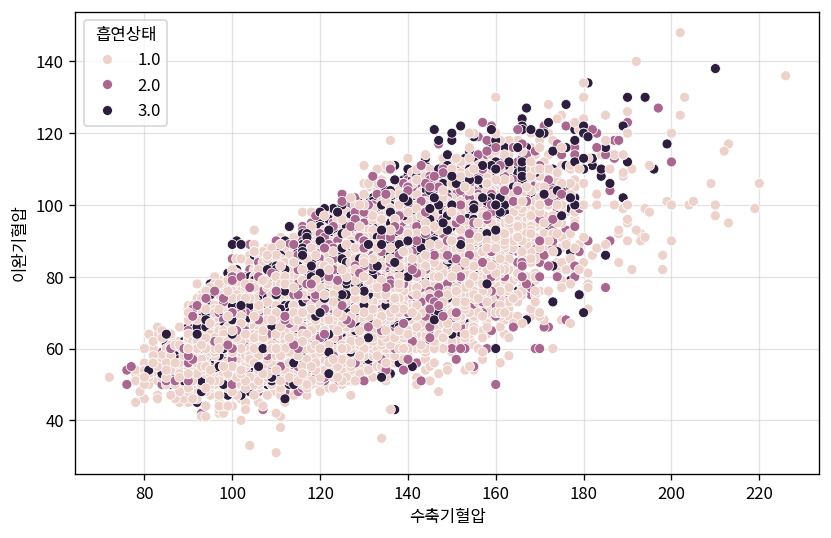

In [13]:
# 혈압 데이터의 상관관계 분석하기.
# 수칙기 혈압과 이완기 혈압의 상관관계를 파악해보고, 흡연 상태에 따라서 값이 어떻게 차이나는지 확인해보기.
# 산점도를 그려서 확인해보기.
sns.scatterplot(x=df['수축기혈압'], y=df['이완기혈압'], hue=df['흡연상태'])

# 수축기 혈압과 이완기 혈압은 서로 양의 상관관계를 보임.
# 흡연 상태가 1.0인 사람들도 혈압이 높은 경우도 있고, 흡연 상태가 3.0인 사람들도 혈압이 낮은 경우도 있는 것으로 보아, 흡연 상태가 혈압에 큰 영향을 미치는 것은 아닌 것 같음.

<Axes: xlabel='신장', ylabel='체중'>

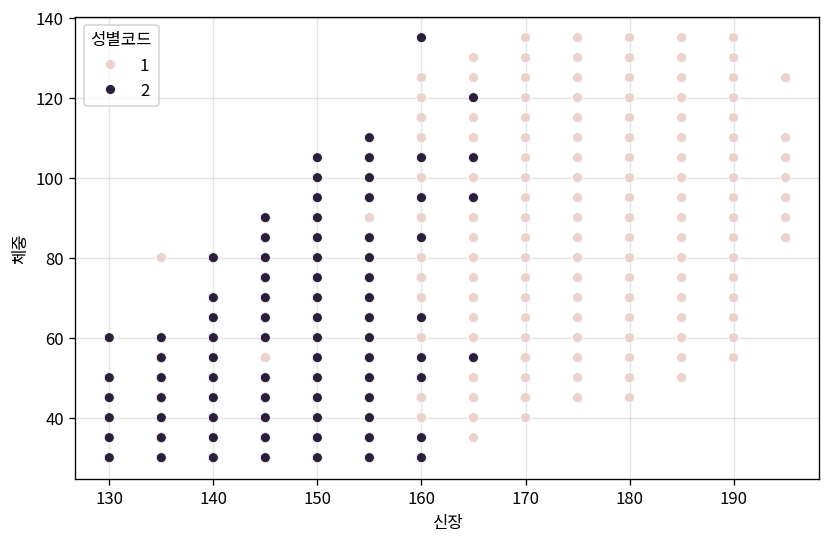

In [15]:
# 신장과 체중의 상관관계 구하기.
# 신장과 체중, 성별 코드를 이용해 산점도를 생성하여 값의 분포를 확인하기.
sns.scatterplot(x=df['신장'], y=df['체중'], hue=df['성별코드'])

# 성별코드가 1, 2로만 나오지만 산점도를 보면 1은 남성, 2는 여성임을 알 수 있음.
# 남성(성별코드 1)인 사람 중 키가 160cm 미만인 경우도 존재하는데, 이는 매우 어린 청소년이나 노인일 것 같음.
# 남성(성별코드 1)인 사람 중 190cm보다 더 큰 경우는 이상치가 아니라고 판단하는게 맞을 것 같음. 키가 2m인 사람도 존재할테니까.
# 여성(성별코드 2)인 사람 중 170cm 이상인 사람은 존재하지 않는 것으로 확인됨.
# 남성과 여성 모두 신장과 체중 간 양의 상관관계가 존재하는 것을 확인할 수 있음.

<Axes: xlabel='혈당', ylabel='총콜레스테롤'>

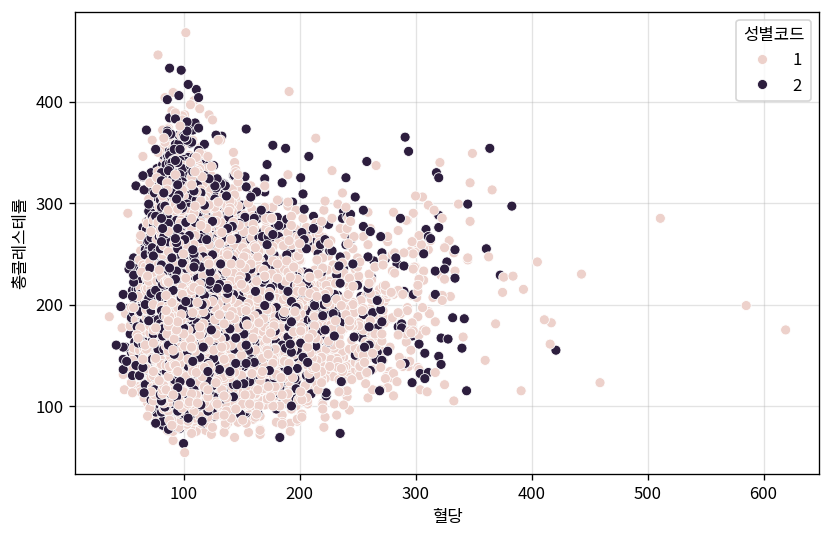

In [ ]:
# 혈당과 총 콜레스테롤의 상관관계 구하기.
# 산점도를 생성하여 혈당과 총 콜레스테롤 간 상관관계를 확인해보기.
sns.scatterplot(x=df['혈당'], y=df['총콜레스테롤'], hue=df['성별코드'])

# 이 두 요소의 상관관계를 정의내리긴 조금 어려울 것 같다고 판단됨.
# 이유 01. 혈당이 400 이상인 남성 중 총 콜레스테롤 수치가 그렇게 높지 않은 사람도 존재함.
# 이유 02. 혈당이 낮다고 해서 총 콜레스테롤 수치가 무조건 낮은 것이 아님.
# 이유 03. 혈당이 높은 사람들이 무조건 총 콜레스테롤 수치가 높은 것도 아님.
# 그래서 혈당과 총 콜레스테롤 수치는 양의 상관관계 또는 음의 상관관계라고 정하기가 어려워 보임.
# 남성보다는 여성이 대체적으로 혈당이 낮은 양상을 보이는 것을 볼 수 있음.

<Axes: xlabel='연령코드', ylabel='총콜레스테롤'>

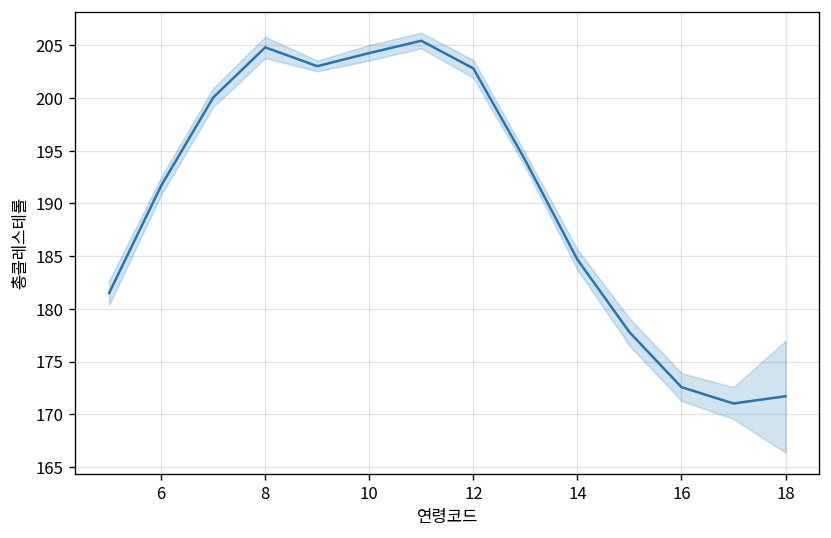

In [ ]:
# 나이에 따른 총 콜레스테롤 추이
# 나이에 따른 총 콜레스테롤 수치의 추이를 확인하기 위해 선 그래프를 생성하기.
sns.lineplot(x=df['연령코드'], y=df['총콜레스테롤'])

# 성별에 관계없이 연령대 별 총 콜레스테롤 수치를 확인하기 위한 선 그래프 생성.
# 연령코드는 x축의 각 값에 '*5'를 하면 됨.
# 즉, 6은 30대, 8은 40대, ..., 16은 80대, 18은 90대가 됨.
# 30대부터 총 콜레스테롤 수치가 증가하다가 40대부터 60대까지 최고점을 찍은 채로 유지함.
# 그러다가 60대 이후부터는 총 콜레스테롤 수치가 감소하는 모습을 보임.
# 파란색 선 위아래로 하늘색 면적은 총 콜레스테롤 수치의 편차임.
# 총 콜레스테롤 수치의 편차는 70대 이후 커지기 시작하고, 80대부터 급격하게 커짐.
# 조사에 참여한 사람들 중 80대 이상의 사람들이 총 콜레스테롤 수치가 가장 낮은 것으로 확인됨.
# 조사에 참여하는 사람이 많아져도, 과연 80대 이상의 사람들이 총 콜레스테롤 수치가 가장 낮은 상태를 유지할까?

<Axes: xlabel='연령코드', ylabel='혈색소'>

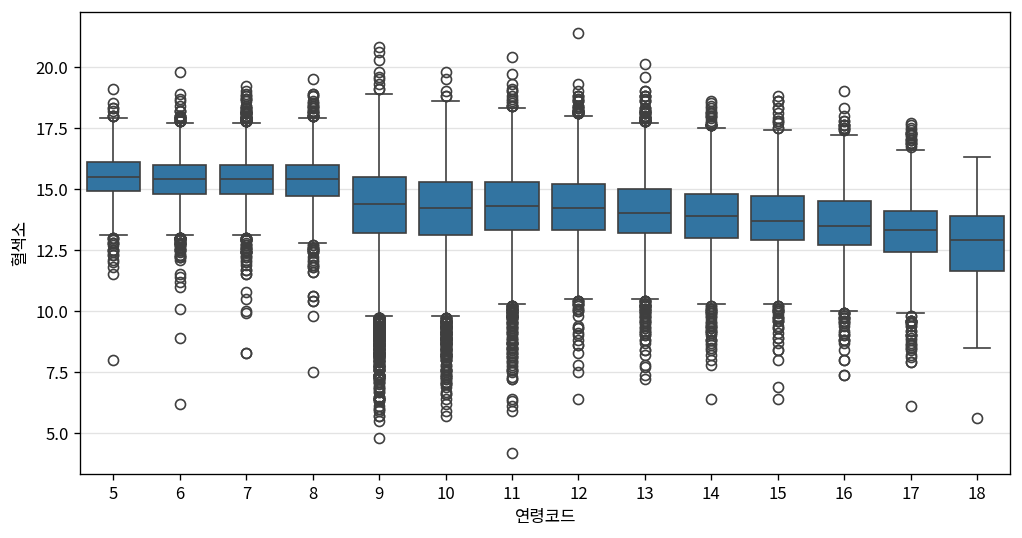

In [ ]:
# 연령에 따른 혈색소 수치의 분포 확인하기.
# 연령에 따른 혈색소 수치의 분포를 확인하기 위해 박스플롯 생성하기.
fig = plt.figure(figsize=(10, 5))
sns.boxplot(x=df['연령코드'], y=df['혈색소'])

# 연령대 별로 혈색소의 중앙값은 비슷한 양상을 보임.
# 25살 ~ 44살 까지의 혈색소 수치의 중앙값이 서로 거의 동일한 수준.
# 45살부터 90살 까지의 혈색소 수치의 중앙값도 거의 동일한 수준.
# 모든 연령대가 공통적으로 혈색소 수치의 최댓값과 최솟값의 편차가 크게 나타남.
# 45세 이상의 혈색소 수치의 최댓값 및 최솟값의 편차가 45세 미만의 혈색소 수치의 최댓값 및 최솟값의 편차보다 더 큼.

<Axes: xlabel='연령코드', ylabel='혈당'>

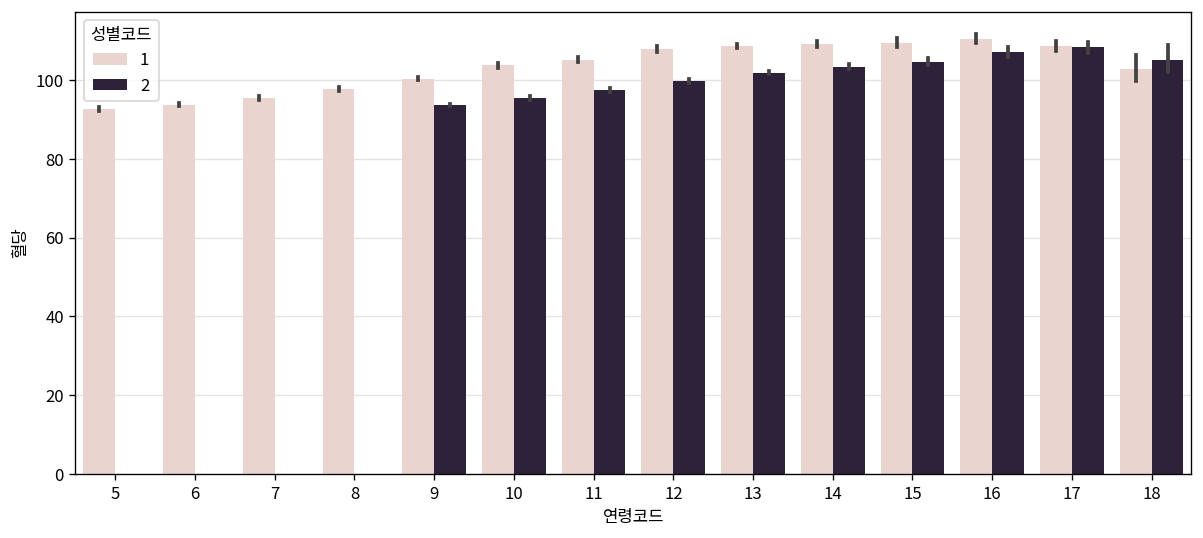

In [ ]:
# 연령과 성별에 따른 혈당 분석하기.
# 연령에 따른 혈당값과 성별에 따른 혈당값의 차이를 확인하기 위해 막대 그래프를 생성.
fig = plt.figure(figsize = (12, 5))
sns.barplot(x=df['연령코드'], y = df['혈당'], hue = df['성별코드'])

# 성별코드가 5~8의 여성 막대 그래프가 보이지 않음.
# 처음에는 남성과 여성의 수치가 같아서 막대가 두 개가 아닌 하나만 생성된 줄 알았음.
# ChatGPT에 확인해보니, 수치가 같으면 같은 채로 두 개의 막대가 생성되는 것이 정상이라고 함.
# 그래서 여성은 연령 코드 5~8의 혈당 값이 없기 때문에 막대가 생성되지 않는 것이라고 함.
# 그래서 아래 셸에 확인용 코드 두 개를 작성해서 직접 봤음.

# 매우 근소하지만, 연령이 높아질수록 혈당 수치도 조금씩 증가하는 양상을 볼 수 있음.
# 85세 이상과 45세 미만을 제외한 나머지 연령대에서는 남성이 여성보다 혈당값이 적은 차이로 더 높은 것을 확인할 수 있음.
# 다른 연령에 비해 90세 이상의 남녀의 혈당 수치의 편차가 제일 큰 것을 확인할 수 있음.

In [24]:
# DF에 연령코드 5~8의 여성의 혈당 값이 있는지를 확인하기 위한 코드 01.
# 연령코드 5~8은 남성의 혈당 값만 존재하고, 여성의 혈당 값이 없는 것을 확인할 수 있었음.
# 왜냐면 연령코드 9부터는 남성과 여성이 각각 데이터의 개수와 평균이 존재하기 때문.
df.groupby(['연령코드', '성별코드'])['혈당'].agg(['count', 'mean'])

count        mean
연령코드 성별코드                   
5    1      2816   92.581676
6    1      5614   93.788742
7    1      5822   95.458949
8    1      5011   97.645779
9    1     11806  100.346349
     2      9167   93.685175
10   1      5308  103.807460
     2      4756   95.427670
11   1      5743  105.130768
     2      5353   97.443116
12   1      4755  107.907256
     2      5042   99.753074
13   1      8506  108.633553
     2      8912  101.919098
14   1      3350  109.202090
     2      3894  103.388290
15   1      1804  109.532705
     2      1911  104.639456
16   1      1601  110.525297
     2      1669  107.077891
17   1      1216  108.555921
     2      1229  108.337673
18   1       110  102.845455
     2       105  105.114286

In [25]:
# 연령코드 5~8의 여성의 혈당값이 존재하는지를 확인하기 위한 코드 02
# 위의 코드의 결과물보다 훨씬 짧고 보기 좋게 출력됨.
# 연령코드가 5~8의 여성의 혈당값이 NaN인 것이 확인됨.
# 따라서 연령코드가 5~8의 여성의 혈당값이 존재하지 않기 때문에, 정상적으로 막대 그래프에서 막대가 존재하지 않는 것이 확인되었음.
df.groupby(['연령코드', '성별코드'])['혈당'].count().unstack()

성별코드,1,2
연령코드,,
5,2816.0,NaN
6,5614.0,NaN
7,5822.0,NaN
8,5011.0,NaN
9,11806.0,9167.0
10,5308.0,4756.0
11,5743.0,5353.0
12,4755.0,5042.0
13,8506.0,8912.0


<Axes: xlabel='연령코드', ylabel='허리둘레'>

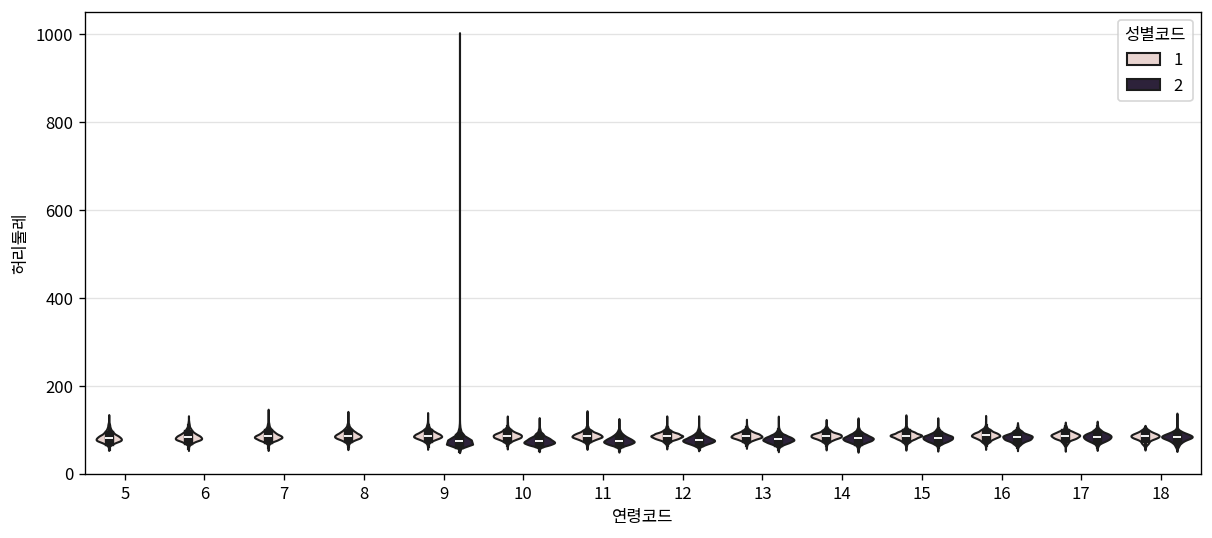

In [ ]:
# 나이에 따른 허리 둘레 분포 확인하기.
# 바이올린플롯을 사용하여 연령코드별 허리둘레의 분포를 시각화하기.
fig = plt.figure(figsize=(12, 5))
sns.violinplot(x=df['연령코드'], y=df['허리둘레'], hue=df['성별코드'])\

# 허리둘레도 혈당처럼 45세 미만의 여성에 대한 데이터는 존재하지 않는 것을 확인할 수 있음.
# 그래서 연령코드 8까지의 바이올린플롯은 한 개씩 생성되었음.

# 남성과 여성 모두 허리 둘레의 최댓값과 최솟값의 편차가 크지 않은 것을 확인할 수 있음.
# 그러나 45~49세 여성에게서 유일하게 허리 둘레의 최댓값과 최솟값의 편차가 매우 큰 것이 확인됨.
# 이상치일까, 아니면 단순히 특정 여성의 허리 둘레가 굉장히 길어서 이런 바이올린플롯이 생성된걸까?

<Axes: xlabel='연령코드', ylabel='시도코드'>

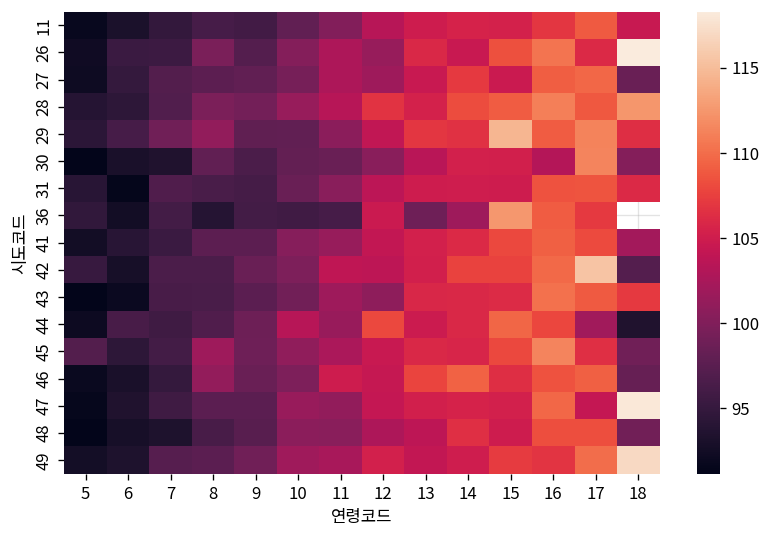

In [ ]:
# 지역과 연령에 따른 혈당 수치 히트맵 생성하기.
# 지역과 연령에 따른 혈당 수치의 분포를 확인하기 위해 히트맵을 생성하기.
pivot_df = df.pivot_table("혈당", "시도코드", "연령코드")
sns.heatmap(pivot_df)

# 우선 시도에 상관없이, 연령이 높아질수록 혈당 수치가 높아지는 것을 색의 채도로 알 수 있음. (히트맵의 특성)
# 채도가 높을수록 혈당 수치가 낮은 것이고, 채도가 낮을수록 혈당 수치가 높아짐.
# 절반 정도의 시도에서는 연령대가 높아질수록 혈당 수치가 높아지는 양상을 보이고, 나머지 절반의 시도는 혈당 수치가 높아지다가 90세 이상에 반대로 혈당 수치가 급격히 낮음.
# 과연 혈당이 높은 지역은 어디이고, 혈당이 낮은 지역은 어디일까? 

In [30]:
# 책에서 얻었다고 기재한 인사이트

# 01. 남성이 여성보다 평균 혈당 수치가 높다.
# 02. 나이가 증가할수록 총 콜레스테롤과 혈당 수치가 증가하는 경향이 있다.
# 03. 신장과 체중, 수축기 혈압과 이완기 혈압 간 양의 상관관계가 존재한다.
# 04. 지역에 상관없이 연령 증가에 따른 혈당 수치 증가 패턴이 일관되게 나타난다.
# 05. 일부 극값들이 전체 분포의 분석을 방해하기 때문에, 추가 데이터 정제가 필요하다.